# RQ2 - Does instruction type affect RAPL accuracy?
## Experiment E1 - Coffee Lake, instruction-set workload

Cells are **verbatim** from `instructiontype_expanded.ipynb`. See `../KNOWN_ISSUES.md`.

**Outputs:** `skesd_sample_coffee.pkl`, Kruskal/Dunn CSVs.


## Data preparation


In [1]:
#this method is updated since Oct 21. A better implementation would be to skip the header, then just use vectorized operation from numpy.
#binparserGraph
#binparserTemp
#temporary binary parser before we can get xml analysis working

import os
import struct
import pandas as pd
import numpy as np

def parse_payload(payload: bytes):
    # payload = 4B header + 8B timestamp + 70B data (14×5B entries)
    timestamp = struct.unpack('<Q', payload[4:12])[0]
    entries = payload[12:]
    data_dict = {}
    for i in range(0, len(entries), 5):
        char_id = chr(entries[i])
        value = struct.unpack('<f', entries[i+1:i+5])[0]
        data_dict[char_id] = value
    return timestamp, data_dict

def parse_binary_folder(folder_path: str):
    # 4-byte discard field, then 8-byte timestamp, then 16 × (1-byte id + 4-byte float)
    record_dtype = np.dtype([
        ('_discard', '4u1'),                 # 4 bytes
        ('timestamp', '<u8'),                # 8 bytes (uint64)
        ('pairs', [('id', 'u1'), ('data', '<f4')], (16,))  # 16 × (1+4)
    ])
    record_size = record_dtype.itemsize  # should be 92 bytes

    files = sorted(
        [f for f in os.listdir(folder_path) if f.startswith('data') and f.endswith('.bin')],
        key=lambda x: int(x[4:-4])
    )

    timestamps_all = []
    id_arrays = {i: [] for i in range(16)}  # accumulate data columns by slot
    id_chars = None                         # to hold column names (char IDs)

    for filename in files:
        path = os.path.join(folder_path, filename)

        with open(path, 'rb') as f:
            data_bytes = f.read()  # read entire file (no header)
            n_records = len(data_bytes) // record_size
            if n_records == 0:
                continue

            # vectorized read
            arr = np.frombuffer(data_bytes, dtype=record_dtype, count=n_records)

            timestamps = arr['timestamp']
            ids = arr['pairs']['id']       # shape (n_records, 16)
            vals = arr['pairs']['data']    # shape (n_records, 16)

            timestamps_all.append(timestamps)

            # verify consistent IDs per column
            first_ids = ids[0, :]
            if not np.all(ids == first_ids):
                mismatched = np.nonzero(~np.all(ids == first_ids, axis=1))[0][:5]
                print(f"\n[DEBUG] ID mismatch in file {filename}: showing first {len(mismatched)} bad rows")
                print("Expected IDs (bytes):", " ".join(f"{b:02X}" for b in first_ids))
                for idx in mismatched:
                    raw_hex = " ".join(f"{b:02X}" for b in ids[idx])
                    print(f"  Row {idx:>6}: {raw_hex}")
                raise ValueError(f"File {filename} has mixed IDs per column!")

            # store char representations once (from first file)
            if id_chars is None:
                id_chars = [chr(x) for x in first_ids]

            # accumulate per-ID arrays
            for i, id_val in enumerate(first_ids):
                id_arrays[i].append(vals[:, i])

    if not timestamps_all:
        raise ValueError("No valid records found in folder!")

    # concatenate across files
    timestamps_all = np.concatenate(timestamps_all)
    data_cols = {}
    for i, chunks in id_arrays.items():
        if len(chunks) == 0:
            continue
        colname = id_chars[i] if id_chars is not None else f"id_{i}"
        data_cols[colname] = np.concatenate(chunks)

    # Build DataFrame
    df = pd.DataFrame(data_cols)
    df.insert(0, "timestamp", timestamps_all.astype(np.uint64))

    return df

def find_rollovers(df):
    if df['timestamp'].dtype != 'uint64':
        df['timestamp'] = df['timestamp'].astype('uint64')

    # Diff using int64 to preserve exact rollover detection
    diffs = df['timestamp'].astype('int64').diff()

    rollover_points = df.index[diffs < 0].tolist()

    for idx in rollover_points:
        t_before = df.loc[idx - 1, 'timestamp']
        t_after = df.loc[idx, 'timestamp']
        print(f"Timestamp rollover at index {idx}: {t_before} → {t_after}")

    return rollover_points

# Example usage:
df = parse_binary_folder('../data/E1-coffeelake-instructions/teensy')
print(df.head(150))

print (df.iloc[12:75].head(10))

rollover = find_rollovers(df)
print(rollover)

print(df.shape)

          timestamp         A         B         C         D         H  \
0    17374778951835  1.143878  0.057194  0.903664  0.228776  0.022878   
1    17374779549002  1.315460  0.057194  1.052368  0.228776  0.000000   
2    17374780146419  0.995174  0.057194  0.800715  0.228776  0.022878   
3    17374780743710  1.121001  0.057194  0.857909  0.228776  0.000000   
4    17374781340877  1.029491  0.057194  0.857909  0.228776  0.022878   
..              ...       ...       ...       ...       ...       ...   
145  17374865552059  1.029491  0.057194  0.846470  0.228776  0.022878   
146  17374866149600  1.086684  0.057194  0.903664  0.228776  0.022878   
147  17374866747184  1.201072  0.057194  1.143878  0.228776  0.000000   
148  17374867344559  1.212511  0.057194  0.972297  0.228776  0.022878   
149  17374867941767  1.143878  0.057194  0.972297  0.228776  0.022878   

            I         J         K         Y         Z         O         P  \
0    2.699553  0.022878  0.125827  3.753040  4

In [4]:
# USE ONLY FOR ONLY TEENSY
import pandas as pd

def correct_timestamp_overflow(df: pd.DataFrame, time_col: str = "timestamp",
                               overflow_points=None, overflow_constant=None) -> pd.DataFrame:
    """
    Correct timestamp overflows by adding multiples of overflow_constant
    after each detected overflow point.

    Parameters:
        df (pd.DataFrame): Input DataFrame with timestamp column.
        time_col (str): Name of the timestamp column.
        overflow_points (list[int]): List of row indices where overflow occurs.
        overflow_constant (int): The value to add after each overflow (e.g. 2**32).
    
    Returns:
        pd.DataFrame: Copy of df with corrected timestamp column.
    """
    if overflow_points is None or overflow_constant is None:
        raise ValueError("Must provide overflow_points and overflow_constant")

    result_df = df.copy()
    corrected = result_df[time_col].astype("int64").copy()

    offset = 0
    current_overflow_idx = 0

    # Iterate over rows, adding offsets after each overflow point
    for i in range(len(corrected)):
        if (current_overflow_idx < len(overflow_points)
                and i >= overflow_points[current_overflow_idx]):
            # Passed an overflow point -> increase offset
            current_overflow_idx += 1
            offset += overflow_constant
        corrected.iloc[i] += offset

    result_df[time_col] = corrected
    return result_df

# Overflow constant for 32-bit counter converted to nanosecond
OVERFLOW_CONST = 2**32 * 125 / 3

corrected_df = correct_timestamp_overflow(df, overflow_points=rollover, overflow_constant=OVERFLOW_CONST)

#print(corrected_df.head(10))
testrollover= find_rollovers(corrected_df)
print(testrollover)
#print(corrected_df.iloc[120:135].head(10))
#print(df.iloc[120:135].head(10))
import matplotlib.pyplot as plt

ts_sub = corrected_df["timestamp"].iloc[::100].reset_index(drop=True)

# Plot timestamp vs index
plt.figure(figsize=(8, 4))
plt.plot(ts_sub.index, ts_sub, marker='o', linestyle='-', linewidth=1)

plt.xlabel("Index (every 100th sample)")
plt.ylabel("Timestamp")
plt.title("Timestamp progression (subsampled every 100 elements)")
plt.grid(True)
plt.tight_layout()
plt.show()

KeyboardInterrupt: 

🗑️  Dropped 5 rows around 1 overflow point(s).
[]


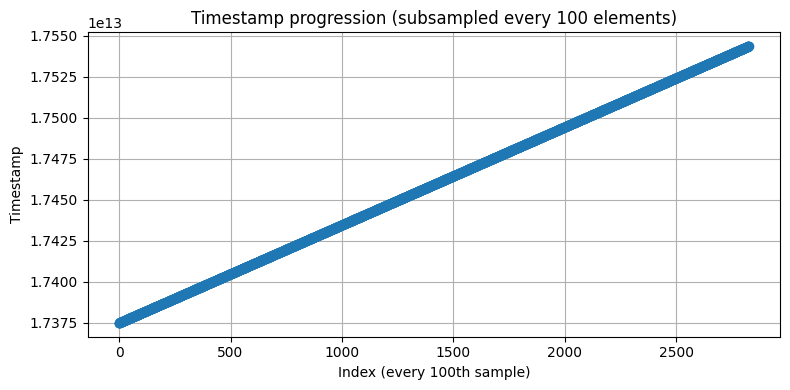

In [2]:
#drop rows time anomaly
#sometimes there WILL BE race conditions causing time anomalies, very few. 2 datapoints every 10,000 or so
#   this function is the alternative to fixing overflows. This one drops 2 before and after the anomaly singleton. 
import pandas as pd

def drop_around_overflows(df: pd.DataFrame,
                          overflow_points: list[int],
                          time_col: str = "timestamp",
                          window: int = 2) -> pd.DataFrame:
    """
    Drop rows around each overflow point, including the overflow itself.

    Parameters:
        df (pd.DataFrame): Input DataFrame.
        overflow_points (list[int]): List of row indices where overflow occurs.
        time_col (str): Timestamp column name (for reference/logging).
        window (int): Number of rows before and after to drop around each overflow point.

    Returns:
        pd.DataFrame: Copy of df with affected rows removed.
    """
    if overflow_points is None or len(overflow_points) == 0:
        print("⚠️ No overflow points provided — returning original DataFrame.")
        return df.copy()

    n_rows = len(df)
    to_drop = set()

    # For each overflow index, mark rows to drop: (i - window) ... (i + window)
    for idx in overflow_points:
        start = max(0, idx - window)
        end = min(n_rows - 1, idx + window)
        to_drop.update(range(start, end + 1))

    result_df = df.drop(index=sorted(to_drop))
    dropped_count = len(to_drop)

    print(f"🗑️  Dropped {dropped_count} rows around {len(overflow_points)} overflow point(s).")
    return result_df.reset_index(drop=True)

corrected_df = drop_around_overflows(df, overflow_points=rollover)
leftover = find_rollovers(corrected_df)
print(leftover)
import matplotlib.pyplot as plt
ts_sub_1 = corrected_df["timestamp"].iloc[::100].reset_index(drop=True)
# Plot timestamp vs index
plt.figure(figsize=(8, 4))
plt.plot(ts_sub_1.index, ts_sub_1, marker='o', linestyle='-', linewidth=1)

plt.xlabel("Index (every 100th sample)")
plt.ylabel("Timestamp")
plt.title("Timestamp progression (subsampled every 100 elements)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [3]:
#use this to read rapl if it's PKG, DRAM and PSYS
SAMP_PATH = "../data/E1-coffeelake-instructions/rapl"

import os
import glob
import numpy as np
import pandas as pd
import struct

import os
import glob
import numpy as np
import pandas as pd

def read_rapl_binaries(SAMP_PATH):
    """
    Reads all binary files written by flush_to_file() in C:
        fwrite(ts_buf, sizeof(int64_t), BUF_SIZE, f);
        fwrite(e_buf, sizeof(float),   BUF_SIZE, f);

    Each file contains two contiguous arrays:
        - timestamps (int64 nanoseconds)
        - energy samples (float32 joules)
    Returns a pandas DataFrame with columns ['timestamp_ns', 'energy'].
    """

    # Match pattern like rapl_YYYYMMDD_HHMMSS_###.bin
    files = sorted(glob.glob(os.path.join(SAMP_PATH, "rapl_????????_??????_???.bin")))
    if not files:
        raise FileNotFoundError(f"No RAPL binary files found in {SAMP_PATH}")

    dfs = []
    for fname in files:
        with open(fname, "rb") as f:
            raw = f.read()

        # Each file contains BUF_SIZE timestamps (8 bytes each) + BUF_SIZE floats (4 bytes each) *3
        # So total length must be divisible by 20
        if len(raw) % 20 != 0:
            raise ValueError(f"File {fname} length {len(raw)} not multiple of 20 bytes")

        # Determine number of samples
        total_bytes = len(raw)
        n_samples = total_bytes // 20

        # Split manually
        ts_bytes = raw[:n_samples * 8]
        pkg_bytes = raw[n_samples * 8 : n_samples * 12]
        dram_bytes  =  raw[n_samples * 12 : n_samples * 16 ]
        psys_bytes  = raw[n_samples * 16:]

        timestamps = np.frombuffer(ts_bytes, dtype="<u8")  # little-endian int64
        energy_pkg     = np.frombuffer(pkg_bytes,  dtype="<f4")  # little-endian float32
        energy_dram     = np.frombuffer(dram_bytes,  dtype="<f4")  # little-endian float32
        energy_psys     = np.frombuffer(psys_bytes,  dtype="<f4")  # little-endian float32


        if len(timestamps) != len(energy_pkg):
            raise ValueError(f"Timestamp and energy count mismatch in {fname}")

        df = pd.DataFrame({
            "timestamp": timestamps,
            "energy_pkg" : energy_pkg,
            "energy_dram" : energy_dram,
            "energy_psys" : energy_psys,
        })
        df["energy"] = df["energy_pkg"]
        dfs.append(df)

    # Combine all
    df_all = pd.concat(dfs, ignore_index=True)
    return df_all

df_rapl = read_rapl_binaries(SAMP_PATH)
print(df_rapl.head(10))
print(df_rapl.shape)

        timestamp  energy_pkg  energy_dram  energy_psys    energy
0  17352798316990    0.008789     0.002563          0.0  0.008789
1  17352799303162    0.010559     0.003052          0.0  0.010559
2  17352800251703    0.007507     0.001709          0.0  0.007507
3  17352801291663    0.008301     0.002075          0.0  0.008301
4  17352802276547    0.008545     0.001953          0.0  0.008545
5  17352803292965    0.006409     0.001282          0.0  0.006409
6  17352804299661    0.005554     0.001404          0.0  0.005554
7  17352805268420    0.010620     0.003235          0.0  0.010620
8  17352806310943    0.008789     0.002319          0.0  0.008789
9  17352807284294    0.007263     0.002136          0.0  0.007263
(180000, 5)


Index(['timestamp', 'energy_pkg', 'energy_dram', 'energy_psys', 'energy'], dtype='object')
0.032433912
0.14483643
outliers:
Empty DataFrame
Columns: [timestamp, energy_pkg, energy_dram, energy_psys, energy]
Index: []
pruned 0 outliers
0.032433912
(180000, 5)
17532794004373
17352798316990
17442795548746.117
outliers:
Empty DataFrame
Columns: [timestamp, energy_pkg, energy_dram, energy_psys, energy]
Index: []
pruned 0 outliers
17442795548746.117
(180000, 5)
Found these rows duplicated observations.
             timestamp  energy_pkg  energy_dram  energy_psys    energy
6881    17359679263255    0.003784     0.000977          0.0  0.003784
16881   17359679263255    0.003784     0.000977          0.0  0.003784
6882    17359680225270    0.004578     0.000977          0.0  0.004578
16882   17359680225270    0.004578     0.000000          0.0  0.004578
18881   17371679024279    0.003601     0.000854          0.0  0.003601
28881   17371679024279    0.003601     0.000854          0.0  0.003601
1

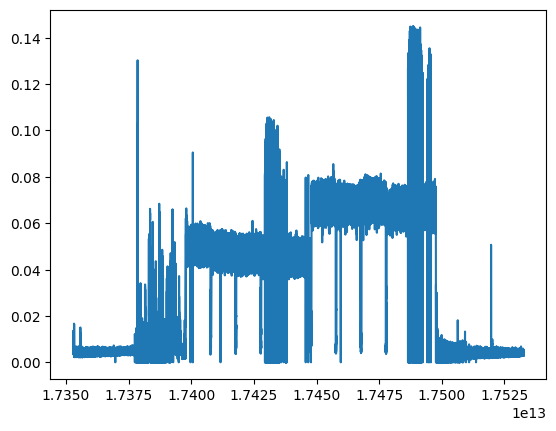

In [4]:
# data cleaning steps 
# prune outliers that look like 262143.968750, cause is unclear.
print(df_rapl.columns)
print(df_rapl["energy_pkg"].mean())
print(df_rapl["energy_pkg"].max())

df_outliers = df_rapl[df_rapl["energy_pkg"] > 200000]
print("outliers:")
print(df_outliers)

df_temp2 = df_rapl[df_rapl["energy_pkg"] < 200000]
print(f"pruned {len(df_rapl) - len(df_temp2)} outliers")
print(df_temp2["energy_pkg"].mean())
print(df_temp2.shape)

df_rapl=df_temp2

print(df_rapl["timestamp"].max())
print(df_rapl["timestamp"].min())
print(df_rapl["timestamp"].mean())

df_outliers = df_rapl[df_rapl["timestamp"] == 0]
print("outliers:")
print(df_outliers)

df_temp3 = df_rapl[df_rapl["timestamp"] != 0]
print(f"pruned {len(df_rapl) - len(df_temp3)} outliers")
print(df_temp3["timestamp"].mean())
print(df_temp3.shape)
df_rapl = df_temp3


duplicated_rows_df = df_rapl[df_rapl.duplicated(subset = ["timestamp"], keep = False)]
duplicated_rows_df = duplicated_rows_df.sort_values(by="timestamp")
print("Found these rows duplicated observations.")
print(duplicated_rows_df)
df_temp4 = df_rapl.drop_duplicates(subset=["timestamp"], keep= 'first')
print(f"dropping {len(df_rapl) - len(df_temp4)} duplicated rows")
df_rapl = df_temp4

import matplotlib.pyplot as plt
plt.plot(df_rapl["timestamp"].values,df_rapl["energy_pkg"].values)
plt.show()

In [5]:
def compute_power_from_energy(df: pd.DataFrame,
                              time_col: str = "timestamp",
                              energy_col: str = "energy") -> pd.DataFrame:
    """
    Compute instantaneous power (Watts) from cumulative energy (Joules)
    using timestamp differences in nanoseconds.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame containing 'timestamp' (ns) and 'energy' (Joule).
    time_col : str, default 'timestamp'
        Column name for timestamp (in nanoseconds).
    energy_col : str, default 'energy'
        Column name for cumulative energy (in Joules).

    Returns
    -------
    pd.DataFrame
        Copy of df with a new 'power' column (float32, in Watts).
    """
    result = df.copy()

    # Compute differences
    dE = result[energy_col]        # ΔEnergy (J)
    dT_ns = result[time_col].diff()        # ΔTime (ns)
    
    # Avoid divide-by-zero or negative intervals
    dT_ns = dT_ns.replace(0, np.nan)

    # Convert ns → seconds and compute power (Watts = J / s)
    result["power"] = (dE / (dT_ns * 1e-9)).astype("float32")

    return result

df_rapl_watt = compute_power_from_energy(df_rapl).dropna()
df_rapl_watt["dram_rapl"] = compute_power_from_energy(df_rapl, energy_col="energy_dram").dropna()["power"]
print(df_rapl_watt.shape)
print(df_rapl_watt.head(5))

(179989, 7)
        timestamp  energy_pkg  energy_dram  energy_psys    energy      power  \
1  17352799303162    0.010559     0.003052          0.0  0.010559  10.707140   
2  17352800251703    0.007507     0.001709          0.0  0.007507   7.914602   
3  17352801291663    0.008301     0.002075          0.0  0.008301   7.981827   
4  17352802276547    0.008545     0.001953          0.0  0.008545   8.676069   
5  17352803292965    0.006409     0.001282          0.0  0.006409   6.305173   

   dram_rapl  
1   3.094549  
2   1.801698  
3   1.995457  
4   1.983102  
5   1.261035  


In [10]:
#df_rapl_watt = df_rapl_watt.iloc[2:]
print(df_rapl_watt.head())

count_zero = (df_rapl_watt["timestamp"]==0).sum()
print(count_zero)
df_rapl_watt = df_rapl_watt[df_rapl_watt["timestamp"] != 0]
count_zero = (df_rapl_watt["timestamp"] ==0).sum()
print(count_zero)



        timestamp  energy_pkg  energy_dram  energy_psys    energy      power  \
1  17352799303162    0.010559     0.003052          0.0  0.010559  10.707140   
2  17352800251703    0.007507     0.001709          0.0  0.007507   7.914602   
3  17352801291663    0.008301     0.002075          0.0  0.008301   7.981827   
4  17352802276547    0.008545     0.001953          0.0  0.008545   8.676069   
5  17352803292965    0.006409     0.001282          0.0  0.006409   6.305173   

   dram_rapl  
1   3.094549  
2   1.801698  
3   1.995457  
4   1.983102  
5   1.261035  
0
0


In [ ]:
# rapl_teensy_merged["cpu_total"] = (rapl_teensy_merged["Y_2"].astype("float32") + rapl_teensy_merged["Z_2"].astype("float32")).astype("float32")
# rapl_teensy_merged["abs_total"] = (rapl_teensy_merged["A_2"]+rapl_teensy_merged["B_2"]+rapl_teensy_merged["C_2"]+rapl_teensy_merged["D_2"]+rapl_teensy_merged["H_2"]+rapl_teensy_merged["I_2"]+rapl_teensy_merged["J_2"]+rapl_teensy_merged["K_2"]+rapl_teensy_merged["Y_2"]+rapl_teensy_merged["Z_2"]+rapl_teensy_merged["O_2"]+rapl_teensy_merged["P_2"]+rapl_teensy_merged["Q_2"]+rapl_teensy_merged["R_2"]+rapl_teensy_merged["U_2"]+rapl_teensy_merged["V_2"])
# rapl_teensy_merged.head(3)

# [commented for review] rapl_teensy_merged["timestamp_s"] = rapl_teensy_merged["timestamp"] / 1000_000_000


segments = [17398106102790, 17408115632950, 17418125344082, 17428134473623, 17438142474785,
             17448150626666, 17458160825127, 17468168994269, 17478177946304,17488185946880, 17498193747238]

workloads = []
workloads.append({"name":"int32", "start_ns":17398106102790, "end_ns":17408115632950})
workloads.append({"name":"int64", "start_ns":17408115632950, "end_ns":17418125344082})
workloads.append({"name":"int128", "start_ns":17418125344082, "end_ns":17428134473623})
workloads.append({"name":"fp32", "start_ns":17428134473623, "end_ns":17438142474785})
workloads.append({"name":"fp64", "start_ns":17438142474785, "end_ns":17448150626666})
workloads.append({"name":"MMX", "start_ns":17448150626666, "end_ns":17458160825127})
workloads.append({"name":"SSE", "start_ns":17458160825127, "end_ns":17468168994269})
workloads.append({"name":"SSE2", "start_ns":17468168994269, "end_ns":17478177946304})
workloads.append({"name":"AVX", "start_ns":17478177946304, "end_ns":17488185946880})
workloads.append({"name":"AVX2", "start_ns":17488185946880, "end_ns":17498193747238})
# input this manually because this was a dataset from before I started saving worload run history in better organized logs











## Energy analysis: RAPL vs sensor per 100 ms window


experiment duration: 17398106102790 to 17498193747238, lasted 100.087644448 s
Index(['timestamp', 'A', 'B', 'C', 'D', 'H', 'I', 'J', 'K', 'Y', 'Z', 'O', 'P',
       'Q', 'R', 'U', 'V', 'timestamp_2', 'cpu_total'],
      dtype='object')
(282355, 19)
Index(['timestamp', 'energy_pkg', 'energy_dram', 'energy_psys', 'energy',
       'power', 'dram_rapl', 'timestamp_1'],
      dtype='object')
(179989, 8)
                 A   B   C   D   H   I   J   K   Y   Z  ...   V  timestamp_2  \
timestamp                                               ...                    
17352799303162 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN          NaN   
17352800251703 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN          NaN   
17352801291663 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN          NaN   
17352802276547 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN          NaN   
17352803292965 NaN NaN NaN NaN NaN NaN NaN NaN NaN NaN  ... NaN          NaN   

                cpu_total  energy_pkg

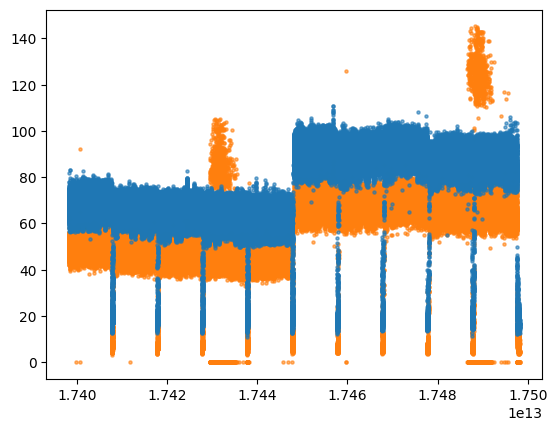

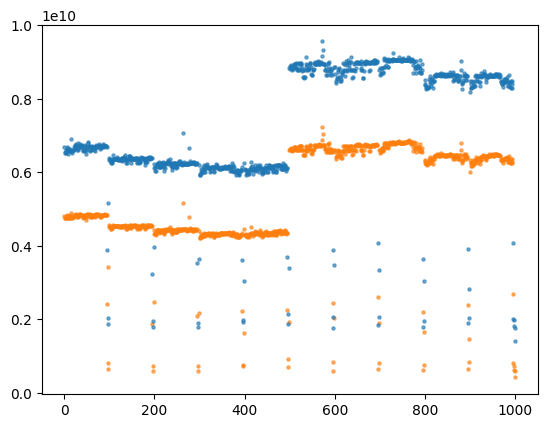

In [8]:
# this section intends to use a jumping window to split the observation into sections where we can observe if the sections are uniform.

# experiment info

workload_start = workloads[0]["start_ns"]
workload_end = workloads[-1]["end_ns"]

print(f"experiment duration: {workload_start} to {workload_end}, lasted {(workload_end - workload_start)/1000_000_000} s")


df_teensy_original = corrected_df
df_teensy_original["cpu_total"] = df_teensy_original["Y"] + df_teensy_original["Z"] + df_teensy_original["U"] + df_teensy_original["V"]
df_rapl_original = df_rapl_watt
print(df_teensy_original.columns) 
print(df_teensy_original.shape)
print(df_rapl_original.columns) 
print(df_rapl_original.shape)

df_teensy_1 = df_teensy_original.set_index("timestamp")
df_rapl_1 = df_rapl_original.set_index("timestamp")
df_merged_outer = pd.merge(df_teensy_1, df_rapl_1, left_index=True, right_index=True, how='outer')
print(df_merged_outer.head())

df_merged_outer = df_merged_outer[(df_merged_outer.index >= workload_start) & (df_merged_outer.index <= workload_end)]

# 1. Create a mask and Group IDs
is_not_nan = df_merged_outer['power'].notna()
group_id = is_not_nan.cumsum()

# 2. Count how many NaNs are in each group
# We only group the rows where 'a' was actually NaN
nan_counts = df_merged_outer[df_merged_outer['power'].isna()].groupby(group_id).size()

# 3. Include the "Zeroes"
# Some non-NaN values might have 0 NaNs following them.
# We reindex to include every group ID from 1 to the total count of non-NaNs.
total_non_nans = is_not_nan.sum()
all_gaps = nan_counts.reindex(np.arange(1, total_non_nans + 1), fill_value=0)

# 4. Final Statistics
stats = {
    'mean': all_gaps.mean(),
    'median': all_gaps.median(),
    'max': all_gaps.max(),
    'min': all_gaps.min()
}

print(stats)
all_gaps = all_gaps.sort_values(ascending = False)
#print(all_gaps.head())
plt.scatter(df_merged_outer.index, df_merged_outer["power"], s=5, color='tab:orange', alpha=0.6, label="rapl")
plt.scatter(df_merged_outer.index, df_merged_outer["cpu_total"], s=5, color='tab:blue', alpha=0.6, label="measured")
plt.show()

import pandas as pd
import numpy as np
import scipy
from scipy.integrate import trapezoid

def integrate_dual_cadence(df, col1, col2, window = 10):
    # 1. Identify rows where 'a' is valid
    is_a_valid = df[col1].notna()
    
    # 2. Create Window IDs based on every 10 valid 'a' values
    # cumsum increments at every valid 'a', then // 10 groups them
    # We subtract 1 so the first group is 0
    a_group_id = (is_a_valid.cumsum() - 1) // window
    
    # 3. Handle Column B's range:
    # Column B needs to integrate everything from the first valid 'a' in the group
    # to just before the first 'a' of the NEXT group.
    # a_group_id naturally covers this range for every row.
    
    # 4. Define the integration logic
    def perform_integration(group):
        # -- Integration for A --
        # Filter only non-NaN a values
        a_data = group[col1].dropna()
        # Trapezoid needs at least 2 points to calculate area
        area_a = scipy.integrate.trapezoid(y=a_data.values, x=a_data.index, dx=1.0, axis=-1) if len(a_data) > 1 else 0
        
        # -- Integration for B --
        # Filter only non-NaN b values
        # This takes all rows in the 10-point 'a' window
        b_data = group[col2].dropna()
        area_b = scipy.integrate.trapezoid(y=b_data.values, x=b_data.index, dx=1.0, axis=-1) if len(b_data) > 1 else 0
        # print(a_data.index)
        # print(len(a_data.index))
        # print(b_data.index)
        # print(len(b_data.index))
        # print("break")

        return pd.Series({'area_a': area_a, 'area_b': area_b})

    # 5. Execute GroupBy
    # We only process groups where a_group_id >= 0 (ignores NaNs at the very start)
    results_df = df[a_group_id >= 0].groupby(a_group_id).apply(perform_integration)
    
    return results_df

# Example usage with dummy data
# df = pd.DataFrame({'a': [...], 'b': [...]})
integrated_results = integrate_dual_cadence(df_merged_outer.head(500000), "power", "cpu_total", window=100)

plt.scatter(integrated_results.index, integrated_results["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
plt.scatter(integrated_results.index, integrated_results["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
plt.show()

## RQ2: Kruskal-Wallis + Dunn post-hoc


<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
686.7376749879359
4.9064106025086266e-142
group
7    811.445545
5    784.257426
6    739.653465
8    669.039604
9    652.811881
0    454.603960
1    288.633663
4    272.465347
2    224.980198
3    157.108911
Name: overall_rank, dtype: float64


C:\Users\andyh\AppData\Local\Temp\ipykernel_8032\3656497930.py:77: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_kruskal_display = pd.concat([df_kruskal_display, sample_df], axis =0)


         median      mean
group                    
0     -0.277896 -0.285813
1     -0.287384 -0.296769
2     -0.289370 -0.299093
3     -0.292118 -0.302467
4     -0.287654 -0.296345
5     -0.248891 -0.260697
6     -0.249746 -0.261615
7     -0.247790 -0.259396
8     -0.251769 -0.263382
9     -0.252045 -0.276562
Index([3, 2, 4, 1, 0, 9, 8, 6, 5, 7], dtype='int64', name='group')
       overall_rank    median      mean  orderPositiveCorrelation
group                                                            
0        454.603960 -0.277896 -0.285813                         4
1        288.633663 -0.287384 -0.296769                         3
2        224.980198 -0.289370 -0.299093                         1
3        157.108911 -0.292118 -0.302467                         0
4        272.465347 -0.287654 -0.296345                         2
5        784.257426 -0.248891 -0.260697                         8
6        739.653465 -0.249746 -0.261615                         7
7        811.445545 -0.2477

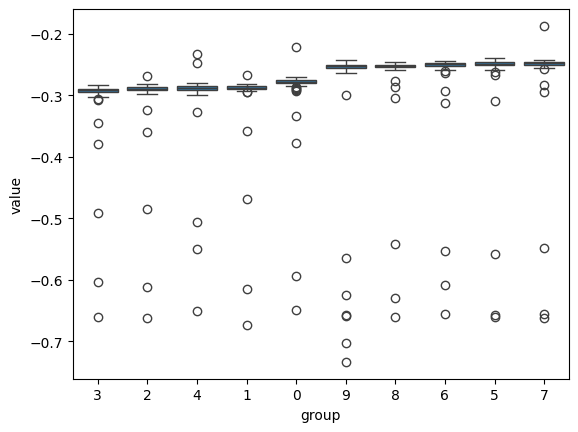

dict_keys(['int32', 'int64', 'int128', 'fp32', 'fp64', 'MMX', 'SSE', 'SSE2', 'AVX', 'AVX2'])
   group workloadname
0      0        int32
1      1        int64
2      2       int128
3      3         fp32
4      4         fp64
5      5          MMX
6      6          SSE
7      7         SSE2
8      8          AVX
9      9         AVX2
   group  overall_rank    median      mean  orderPositiveCorrelation  \
0      0    454.603960 -0.277896 -0.285813                         4   
1      1    288.633663 -0.287384 -0.296769                         3   
2      2    224.980198 -0.289370 -0.299093                         1   
3      3    157.108911 -0.292118 -0.302467                         0   
4      4    272.465347 -0.287654 -0.296345                         2   
5      5    784.257426 -0.248891 -0.260697                         8   
6      6    739.653465 -0.249746 -0.261615                         7   
7      7    811.445545 -0.247790 -0.259396                         9   
8      8    669.0

C:\Users\andyh\AppData\Local\Temp\ipykernel_8032\3656497930.py:142: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(order_with_names)


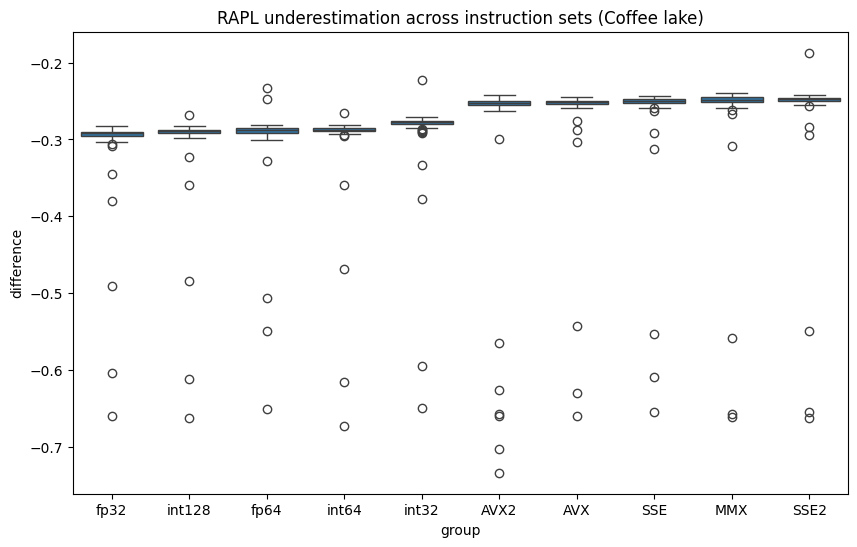

In [10]:
#prepare KW test sample

#print(workloads)

samples_kw = []
for workload in workloads: 
    start_ns = workload["start_ns"]
    end_ns = workload["end_ns"]
    workload_name = workload["name"]
    samples_kw.append(df_merged_outer[(df_merged_outer.index > start_ns) & (df_merged_outer.index < end_ns)])

samples_integrals_kw = []
for sample in samples_kw: 
    samples_integrals_kw.append(integrate_dual_cadence(sample, "power", "cpu_total", window=100))

# for i, sample in enumerate(samples):
#     plt.scatter(samples_integrals[i].index, samples_integrals[i]["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
#     plt.scatter(samples_integrals[i].index, samples_integrals[i]["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
#     plt.show()

samples_by_workload_kw = {}
for i, workload in enumerate(workloads):
    if workload["name"] in samples_by_workload_kw.keys():
        df1 = samples_by_workload_kw[workload["name"]]
        df2 = samples_integrals_kw[i]
        samples_by_workload_kw[workload["name"]] = pd.concat([df1, df2], axis =0)
    else: 
        samples_by_workload_kw[workload["name"]] = samples_integrals_kw[i]
    # print(workload["name"])
    # print(samples_by_workload_kw[workload["name"]].shape)
    
for i, workload in enumerate(workloads):
    df1 = samples_by_workload_kw[workload["name"]]
    df1["diff"] = df1["area_a"] - df1["area_b"]
    df1["diff_normalized"] = df1["diff"] / df1["area_b"]

for i, sample in enumerate(list(samples_by_workload_kw.values())):
    print(type(sample))
    # plt.scatter(sample.index, sample["area_a"], s=5, color='tab:orange', alpha=0.6, label="power (W)")
    # plt.scatter(sample.index, sample["area_b"], s=5, color='tab:blue', alpha=0.6, label="CPU Total (W)")
    # plt.scatter(sample.index, sample["diff"], s=5, color='tab:green', alpha=0.6, label="diff")
    # plt.scatter(sample.index, sample["diff_normalized"], s=5, color='tab:red', alpha=0.6, label="diff normals")
    # plt.show()
    

    

#segments = [17398106102790, 17408115632950, 17418125344082, 17428134473623, 17438142474785, 17448150626666, 17458160825127, 17468168994269, 17478177946304,17488185946880, 17498193747238]

# plot_cpu_vs_energy(rapl_teensy_merged, sample_factor=100, time_col="timestamp", segments=segments)
# for i, workload in enumerate(workloads):
#     print(f"#{i}: {workload['name']}")

# perform kruskal wallis H test on normalized difference for data collected in each instruction set type workload.
# visualize using box plot 
# performs dunns test to determining if the differences are statistically significant 

writepath = "./"

from scipy.stats import kruskal

kruskal_sample = []
for sample in list(samples_by_workload_kw.values()):
    kruskal_sample.append(sample["diff_normalized"])

# Perform Kruskal-Wallis H-test
result = kruskal(*kruskal_sample)

print(result.statistic)
print(result.pvalue)

df_kruskal_display = pd.DataFrame(columns=["value", "group"])
for i, sample in enumerate(kruskal_sample):
    sample_df = pd.DataFrame()
    sample_df["value"] = sample
    sample_df["group"] = i
    df_kruskal_display = pd.concat([df_kruskal_display, sample_df], axis =0)

from scipy.stats import rankdata
df_kruskal_descriptive = pd.DataFrame()

# Combine your data into a DataFrame
# Assume 'value' is the score and 'group' is the category
df_kruskal_display['overall_rank'] = rankdata(df_kruskal_display['value'])

# Get the ranking of the groups
group_rankings = df_kruskal_display.groupby('group')['overall_rank'].mean().sort_values(ascending=False)
df_kruskal_descriptive = df_kruskal_display.groupby("group")["overall_rank"].mean()
print(group_rankings)

import seaborn as sns
import matplotlib.pyplot as plt

# Sort the groups by their median value to visualize the ranking
order = df_kruskal_display.groupby('group')['value'].median().sort_values().index
df_kruskal_median = pd.DataFrame()
df_kruskal_median["median"] = df_kruskal_display.groupby("group")["value"].median()
df_kruskal_median["mean"] = df_kruskal_display.groupby("group")["value"].mean()

df_kruskal_descriptive = pd.merge(df_kruskal_descriptive, df_kruskal_median, on="group")
print(df_kruskal_median)
#df_kruskal_order = df_kruskal_order.set_index("order")
print(order)
order_by_group = pd.Series(range(len(order)), index=order).sort_index()
df_kruskal_descriptive["orderPositiveCorrelation"] = order_by_group
print(df_kruskal_descriptive)

sns.boxplot(x='group', y='value', data=df_kruskal_display, order=order)
plt.show()
print(samples_by_workload_kw.keys())
df_workload_results = pd.DataFrame()
df_workload_results["workloadname"] = samples_by_workload_kw.keys()
df_workload_results = df_workload_results.reset_index(names="group")
print(df_workload_results)
df_kruskal_descriptive = pd.merge(df_kruskal_descriptive, df_workload_results, on="group")
print(df_kruskal_descriptive)
df_kruskal_descriptive['workloadname'] = df_kruskal_descriptive['workloadname']
print(df_kruskal_descriptive)
df_kruskal_descriptive.to_csv((writepath + "Energy_kruskal_results_descriptive_workloadranking.csv"), index = False)
workload_name_mapping = df_kruskal_descriptive.set_index('group')['workloadname'].to_dict()


import scikit_posthocs as sp

# Assuming 'data' is your list of 10 groups
# We pass the list directly to the dunn test function
print("columns")
print(df_kruskal_display.columns)
p_values = sp.posthoc_dunn(df_kruskal_display,val_col="value", group_col="group", p_adjust='bonferroni')
p_values = p_values.mask(p_values < 0.001, "p < 0.001")

p_values = p_values.rename(index=workload_name_mapping, columns=workload_name_mapping)
print(p_values)
p_values.to_csv((writepath + "Energy_dunn_posthoc_pairwise_workload_comparison.csv"))

# df_kruskal_display["workload name"] = df_kruskal_display["group"].map(workload_name_mapping)
# sns.boxplot(x='group', y='value', data=df_kruskal_display, order=order)
order_with_names = [workload_name_mapping.get(id) for id in order]
plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df_kruskal_display, x='group', y='value', order=order)
# override the tick labels 
ax.set_xticklabels(order_with_names)
plt.title("RAPL underestimation across instruction sets (Coffee lake)")
plt.ylabel("difference")
plt.show()





## RQ2: assemble SK-ESD sample matrix (persists `skesd_sample_coffee.pkl`)


In [ ]:
print(samples_by_workload_kw.keys())
scottknott_sample = pd.DataFrame()
for key in samples_by_workload_kw.keys():
    scottknott_sample[key] = samples_by_workload_kw[key]["diff_normalized"]

scottknott_sample.reset_index(drop=True, inplace=True)

print(scottknott_sample.columns)
print(scottknott_sample.head())

# perform the non-parametric equivalent of ScottKnott ESD, NPSK using R bridge on pairwise energy data. 

# uses the scottknott_sample from last cell

# Below code interface with R 

import pandas as pd
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, conversion, default_converter
from rpy2.robjects.packages import importr

# 1. Import the R library
sk_esd_pkg = importr('ScottKnottESD')

# 2. Your data (ensure you have enough observations for a statistical test)
# Data must be dataframe containing separate columns for each groups with equal length.

# # 3. Use the conversion context
# with conversion.localconverter(default_converter + pandas2ri.converter):
#     # Pass the dataframe directly. 
#     # Note: R's 'non.parametric' becomes 'non_parametric' in rpy2
#     sk_result = sk_esd_pkg.sk_esd(df, non_parametric=True)

# remove obects from previous runs 
robjects.r('rm(list = ls(all.names = TRUE))') 

# Assign your dataframe to an R variable named 'r_df'
with robjects.conversion.localconverter(robjects.default_converter + pandas2ri.converter):
    robjects.r.assign("r_df", scottknott_sample)

# Run everything via R strings (No Python-side object handling)
robjects.r('''
    
    library(ScottKnottESD)
    sk <- sk_esd(r_df, non.parametric=TRUE)
    png("scott_knott_plot.png")
    plot(sk)
    dev.off()
           
    # 2. CAPTURE STATISTICS
    # Capture the ANOVA table (Df, Sum Sq, Mean Sq, F-value, Pr(>F))
    anova_summary <- capture.output(summary(sk$av))
    
    # Capture the Group Rankings
    group_summary <- capture.output(print(sk$groups))

    # 3. SAVE STATS TO PNG
    png("scott_knott_stats.png", width=700, height=500)
    plot.new()
    
    # Combine the headers and data into one character vector
    full_output <- c("--- ANOVA Table ---", anova_summary, "", "--- Scott-Knott Grouping ---", group_summary)
    
    # Print the text to the PNG
    # cex=0.9 controls font size; family='mono' keeps columns aligned
    text(x=0, y=1, labels=paste(full_output, collapse="\n"), 
         adj=c(0,1), family="mono", cex=0.9)
    
    dev.off()     
''')

# Pull it from R
sk_list_vector = robjects.r['sk']

# Convert to a standard Python dictionary
with conversion.localconverter(default_converter + pandas2ri.converter):
    # This maps the R names to the Python-converted values
    sk_results_dict = dict(zip(sk_list_vector.names, list(sk_list_vector)))

print(sk_results_dict.keys())

# Access the results
print("--- Scott-Knott ESD Rankings ---")

# SK_ESD RESULT INFORMATION
# av = anova results
# groups = group results
# nms = names
# ord = order
# m.inf = means information
# sig.level = alpha value used in test
print(sk_results_dict.keys())
for key in sk_results_dict.keys(): 
    print(f"Name: {key} ==============================================================")
    obj = sk_results_dict[key]
    if (type(obj) == "arraylike"):
        print(obj)
    else:
        print(list(obj))

print(sk_results_dict["groups"])




dict_keys(['int32', 'int64', 'int128', 'fp32', 'fp64', 'MMX', 'SSE', 'SSE2', 'AVX', 'AVX2'])
Index(['int32', 'int64', 'int128', 'fp32', 'fp64', 'MMX', 'SSE', 'SSE2', 'AVX',
       'AVX2'],
      dtype='object')
      int32     int64    int128      fp32      fp64       MMX       SSE  \
0 -0.280223 -0.289843 -0.293034 -0.293388 -0.292708 -0.254545 -0.249697   
1 -0.273556 -0.286168 -0.289369 -0.289028 -0.285205 -0.249146 -0.250261   
2 -0.272500 -0.286083 -0.285448 -0.284990 -0.286607 -0.253257 -0.245122   
3 -0.271445 -0.283117 -0.285795 -0.289792 -0.290436 -0.255290 -0.244304   
4 -0.273269 -0.289410 -0.294823 -0.290028 -0.285773 -0.249487 -0.247494   

       SSE2       AVX      AVX2  
0 -0.245562 -0.253721 -0.257098  
1 -0.246361 -0.251306 -0.249994  
2 -0.244197 -0.249919 -0.253340  
3 -0.244658 -0.245987 -0.257752  
4 -0.250152 -0.246553 -0.258383  
dict_keys(['av', 'groups', 'nms', 'ord', 'm.inf', 'sig.level'])
--- Scott-Knott ESD Rankings ---
dict_keys(['av', 'groups', 'nms', 'or

## RQ2: Scott-Knott ESD


In [14]:
# Enhanced np sk esd output, but it throws error so Im keeping the old one around just in case.

print(samples_by_workload_kw.keys())
scottknott_sample = pd.DataFrame()
for key in samples_by_workload_kw.keys():
    scottknott_sample[key] = samples_by_workload_kw[key]["diff_normalized"]

scottknott_sample.reset_index(drop=True, inplace=True)

print(scottknott_sample.columns)
print(scottknott_sample.head())

import pickle as pkl
with open("skesd_sample_coffee.pkl", "wb") as file:
    pkl.dump(scottknott_sample, file)

import pandas as pd
import rpy2.robjects as robjects
from rpy2.robjects import pandas2ri, conversion, default_converter
from rpy2.robjects.packages import importr

# 1. Import the R library
sk_esd_pkg = importr('ScottKnottESD')

# Remove objects from previous runs 
robjects.r('rm(list = ls(all.names = TRUE))') 

# Assign your dataframe to an R variable named 'r_df'
with robjects.conversion.localconverter(robjects.default_converter + pandas2ri.converter):
    robjects.r.assign("r_df", scottknott_sample)

# Run everything via R strings (Now with ggplot2)
robjects.r('''
    library(ScottKnottESD)
    library(ggplot2)
    library(svglite)
    
    # 1. Run the Scott-Knott ESD test
    sk <- sk_esd(r_df, non.parametric=TRUE)
    
    # --- GGPLOT2 REMAKE SECTION ---
    # Extract the ranking results into a clean R dataframe for ggplot
    plot_data <- data.frame(
        Group = names(sk$groups),
        Rank  = as.factor(sk$groups)
    )
    
    # Merge with the actual raw data to get distribution values for boxplots
    # Melt/reshape the original data frame into a long format
    raw_long <- stack(r_df)
    names(raw_long) <- c("Value", "Group")
    
    # Combine the raw values with their statistical Scott-Knott ranks
    gg_df <- merge(raw_long, plot_data, by="Group")
    
    # Generate the modern ggplot2 graph
    gg <- ggplot(gg_df, aes(x = reorder(Group, Value, FUN = median), y = Value, fill = Rank)) +
        geom_boxplot(alpha = 0.7, outlier.size = 2) +
        theme_minimal(base_size = 14) +
        scale_fill_brewer(palette = "Set2") + # Distinct colors for different ranks
        labs(
            title = "Scott-Knott ESD Grouping Results",
            subtitle = "Groups sharing a color are statistically identical",
            x = "Treatments / Groups",
            y = "Values",
            fill = "Stat Rank"
        ) +
        theme(
            plot.title = element_text(face = "bold", hjust = 0.5),
            plot.subtitle = element_text(hjust = 0.5, color = "darkgray"),
            axis.text.x = element_text(angle = 45, vjust = 1, hjust = 1) # Tilt labels if they overlap
        )
    
    # Save the ggplot using ggsave (superior to png() for ggplot objects)
    ggsave("scott_knott_ggplot.png", plot = gg, width = 8, height = 6, dpi = 300)
    ggsave("scott_knott_plot.pdf", plot = gg, width = 8, height = 6)
    ggsave("scott_knott_plot.svg", plot = gg, width = 8, height = 6)
    # ------------------------------
           
    # 2. CAPTURE STATISTICS
    anova_summary <- capture.output(summary(sk$av))
    group_summary <- capture.output(print(sk$groups))

    # 3. SAVE STATS TO       
    png("scott_knott_stats.png", width=700, height=500)
    plot.new()
           
    full_output <- c("--- ANOVA Table ---", anova_summary, "", "--- Scott-Knott Grouping ---", group_summary)
    
    text(x=0, y=1, labels=paste(full_output, collapse="\n"), 
         adj=c(0,1), family="mono", cex=0.9)
    
    dev.off()     
''')

# Pull it from R
sk_list_vector = robjects.r['sk']

# Convert to a standard Python dictionary
with conversion.localconverter(default_converter + pandas2ri.converter):
    # This maps the R names to the Python-converted values
    sk_results_dict = dict(zip(sk_list_vector.names, list(sk_list_vector)))

print(sk_results_dict.keys())

# Access the results
print("--- Scott-Knott ESD Rankings ---")

# SK_ESD RESULT INFORMATION
# av = anova results
# groups = group results
# nms = names
# ord = order
# m.inf = means information
# sig.level = alpha value used in test
print(sk_results_dict.keys())
for key in sk_results_dict.keys(): 
    print(f"Name: {key} ==============================================================")
    obj = sk_results_dict[key]
    if (type(obj) == "arraylike"):
        print(obj)
    else:
        print(list(obj))

print(sk_results_dict["groups"])

dict_keys(['int32', 'int64', 'int128', 'fp32', 'fp64', 'MMX', 'SSE', 'SSE2', 'AVX', 'AVX2'])
Index(['int32', 'int64', 'int128', 'fp32', 'fp64', 'MMX', 'SSE', 'SSE2', 'AVX',
       'AVX2'],
      dtype='object')
      int32     int64    int128      fp32      fp64       MMX       SSE  \
0 -0.280223 -0.289843 -0.293034 -0.293388 -0.292708 -0.254545 -0.249697   
1 -0.273556 -0.286168 -0.289369 -0.289028 -0.285205 -0.249146 -0.250261   
2 -0.272500 -0.286083 -0.285448 -0.284990 -0.286607 -0.253257 -0.245122   
3 -0.271445 -0.283117 -0.285795 -0.289792 -0.290436 -0.255290 -0.244304   
4 -0.273269 -0.289410 -0.294823 -0.290028 -0.285773 -0.249487 -0.247494   

       SSE2       AVX      AVX2  
0 -0.245562 -0.253721 -0.257098  
1 -0.246361 -0.251306 -0.249994  
2 -0.244197 -0.249919 -0.253340  
3 -0.244658 -0.245987 -0.257752  
4 -0.250152 -0.246553 -0.258383  
dict_keys(['av', 'groups', 'nms', 'ord', 'm.inf', 'sig.level'])
--- Scott-Knott ESD Rankings ---
dict_keys(['av', 'groups', 'nms', 'or